# 7 · Backends: thermofield-double purification and shot noise

Everything so far ran on the **dense** backend (an exact density matrix). The
backend is a *swap seam*: models, losses, metrics and optimizers are written
against a small protocol, so changing the engine changes nothing in your code.

This notebook covers the **statevector backend**, which represents the Gibbs state
by its **thermofield-double (TFD) purification**

$$|\mathrm{TFD}\rangle = \sum_k \sqrt{p_k}\,|v_k\rangle_{\mathrm{sys}}\otimes|k\rangle_{\mathrm{anc}},
\qquad \mathrm{Tr}_{\mathrm{anc}}\,|\mathrm{TFD}\rangle\langle\mathrm{TFD}| = \rho,$$

and supports an optional **shot budget** to model finite-measurement (hardware)
readout.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qbm
from qbm import purification
from qbm.operators import ParamHamiltonian, local_pauli_generators

print("available backends:", qbm.available_backends())

ham = ParamHamiltonian(local_pauli_generators(3))
theta = np.random.default_rng(0).normal(scale=0.6, size=ham.n_params)
sv = qbm.get_backend("statevector").thermal_state(ham, theta)
psi = sv.tfd_state()
print("TFD statevector length:", psi.shape[0], "= dim^2 =", sv.dim**2)

available backends: ['circuit', 'dense', 'statevector']
TFD statevector length: 64 = dim^2 = 64


### The purification is exact

The reduced state of the TFD equals $\rho$, the purified expectation equals
$\mathrm{Tr}(\rho O)$, and the system–ancilla entanglement entropy equals the
thermal entropy $S(\rho)$.

In [2]:
rho = sv.density_matrix()
print("max |Tr_anc|TFD><TFD| - rho| =",
      np.max(np.abs(purification.reduced_system_state(psi, sv.dim) - rho)))
O = qbm.hamiltonians.tfim(3, g=1.2)
print("<psi|O x I|psi> - Tr(rho O) =",
      abs(purification.expectation(psi, O, sv.dim) - np.real(np.trace(rho @ O))))
print("entanglement entropy - thermal entropy =",
      abs(sv.entanglement_entropy() - sv.entropy()))

max |Tr_anc|TFD><TFD| - rho| = 1.1102230246251565e-16
<psi|O x I|psi> - Tr(rho O) = 4.440892098500626e-16
entanglement entropy - thermal entropy = 2.220446049250313e-16


### Entropy across the "temperature" knob

Scaling all parameters by $s$ acts like lowering the temperature: small $s$ gives a
near-maximally-mixed (high-entropy) state, large $s$ concentrates on the ground
state of $G$ (low entropy). The TFD entanglement entropy tracks the thermal entropy
exactly.

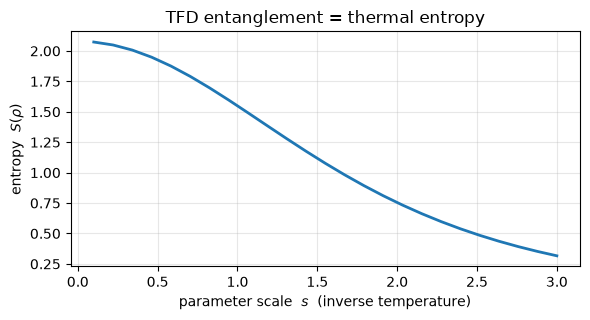

In [3]:
scales = np.linspace(0.1, 3.0, 25)
S = []
for s in scales:
    st = qbm.get_backend("statevector").thermal_state(ham, s * theta)
    S.append(st.entanglement_entropy())
plt.figure(figsize=(6, 3.3))
plt.plot(scales, S, lw=2)
plt.xlabel("parameter scale  $s$  (inverse temperature)")
plt.ylabel("entropy  $S(\\rho)$")
plt.title("TFD entanglement = thermal entropy")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Statevector ≡ dense (exact)

With no shot budget the statevector backend reproduces the dense engine to machine
precision — every model/loss/metric is backend-invariant.

In [4]:
dense = qbm.DenseBackend().thermal_state(ham, theta)
svx = qbm.StatevectorBackend(shots=None).thermal_state(ham, theta)
for name, a, b in [
    ("expect",            dense.expect(O), svx.expect(O)),
    ("max |gen_exp|",     0, np.max(np.abs(dense.generator_expectations() - svx.generator_expectations()))),
    ("max |obs_grad|",    0, np.max(np.abs(dense.observable_gradient(O) - svx.observable_gradient(O)))),
    ("max |metric KM|",   0, np.max(np.abs(dense.metric("kubo_mori") - svx.metric("kubo_mori")))),
]:
    print(f"{name:16s}: {b - a if name=='expect' else b:.2e}")

expect          : 4.44e-16
max |gen_exp|   : 0.00e+00
max |obs_grad|  : 0.00e+00
max |metric KM| : 0.00e+00


### Shot noise

Setting `shots` makes measurement-type quantities (expectations, generator
expectations, samples) into finite-sample estimates — what a real device returns.
The estimate is unbiased and its error shrinks as $1/\sqrt{\text{shots}}$.

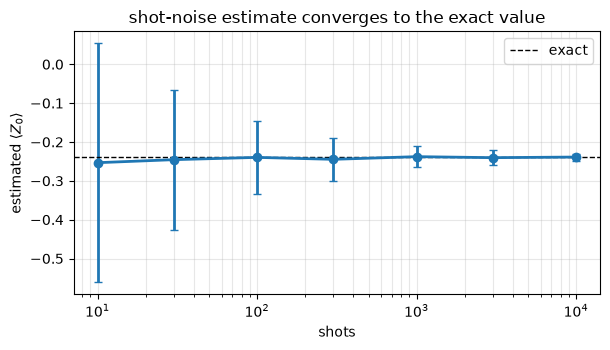

In [5]:
Z0 = qbm.pauli("ZII")
exact = dense.expect(Z0)
shot_grid = [10, 30, 100, 300, 1000, 3000, 10000]
means, stds = [], []
for shots in shot_grid:
    b = qbm.StatevectorBackend(shots=shots, seed=1)
    est = [b.thermal_state(ham, theta).expect(Z0) for _ in range(60)]
    means.append(np.mean(est)); stds.append(np.std(est))

plt.figure(figsize=(6.2, 3.6))
plt.errorbar(shot_grid, means, yerr=stds, fmt="o-", capsize=3, lw=2)
plt.axhline(exact, ls="--", color="k", lw=1, label="exact")
plt.xscale("log"); plt.xlabel("shots"); plt.ylabel(r"estimated $\langle Z_0\rangle$")
plt.title("shot-noise estimate converges to the exact value")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

### Training under a shot budget

Because shot noise flows through `generator_expectations`, relative-entropy /
likelihood training works on a shot budget — letting you study sample complexity
(cf. arXiv:2511.11802). Below, finite-shot training is noisier but still descends.

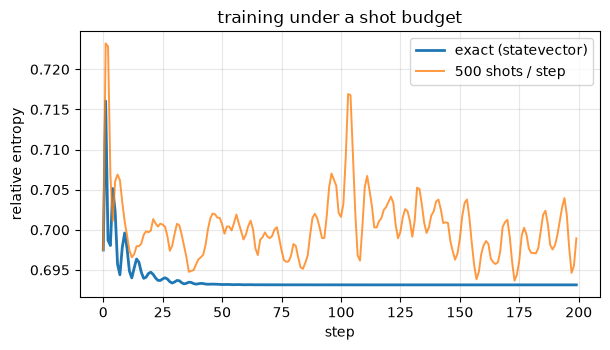

In [6]:
q = qbm.datasets.parity(n=3)
loss = qbm.losses.RelativeEntropy(np.diag(q.astype(complex)))

def train(backend):
    m = qbm.FullyVisibleQBM(n=3, backend=backend)
    m.theta = np.random.default_rng(0).normal(scale=0.05, size=m.n_params)
    return qbm.fit(m, loss, qbm.optim.Adam(lr=0.1), steps=200)

h_exact = train(qbm.StatevectorBackend(shots=None))
h_shots = train(qbm.StatevectorBackend(shots=500, seed=0))

plt.figure(figsize=(6.2, 3.6))
plt.plot(h_exact.loss, lw=2, label="exact (statevector)")
plt.plot(h_shots.loss, lw=1.4, alpha=0.8, label="500 shots / step")
plt.xlabel("step"); plt.ylabel("relative entropy"); plt.legend(); plt.grid(alpha=0.3)
plt.title("training under a shot budget"); plt.tight_layout(); plt.show()

### Recap and what's next

- The statevector backend builds the TFD purification — an exact pure-state view,
  the route to hardware and to entanglement studies.
- A shot budget models finite-measurement readout for sample-complexity research.
- Both run through the same models/losses/metrics/optimizers as the dense engine.

Planned backends (optional extras): **tensor networks** (quimb) for scalable
structured systems, **circuit/hardware** (PennyLane/Qiskit, with VarQITE/QITE/TFD
Gibbs preparation), and **JAX** for autodiff + GPU — each just another
implementation of the same backend protocol.